# Multi-Class Prediction of Obesity Risk — Tree-Based Classification Models

This notebook completes the Kaggle **Multi-Class Prediction of Obesity Risk** task using four required model types:

1. Decision Tree  
2. Bagged Decision Trees  
3. Random Forest  
4. Boosted Trees  

The workflow includes data loading, exploratory analysis, assumption checks, preprocessing, model training, validation, model interpretation, error analysis, and Kaggle submission-file generation.


In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


## 2. Load the Kaggle data

This cell works directly inside Kaggle. If running locally, update `DATA_DIR` to the folder that contains `train.csv`, `test.csv`, and `sample_submission.csv`.


In [3]:
# ============================================================
# 2. Load data
# ============================================================

DATA_DIR = "/kaggle/input/competitions/playground-series-s4e2"

if not os.path.exists(DATA_DIR):
    # Local fallback: place train.csv, test.csv, and sample_submission.csv in the same folder as this notebook
    DATA_DIR = "."

train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")
sample_submission_path = os.path.join(DATA_DIR, "sample_submission.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())


Train shape: (20758, 18)
Test shape: (13840, 17)
Sample submission shape: (13840, 2)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,20758,Male,26.899886,1.848294,120.644178,yes,yes,2.938616,3.000000,Sometimes,no,2.825629,no,0.855400,0.000000,Sometimes,Public_Transportation
1,20759,Female,21.000000,1.600000,66.000000,yes,yes,2.000000,1.000000,Sometimes,no,3.000000,no,1.000000,0.000000,Sometimes,Public_Transportation
2,20760,Female,26.000000,1.643355,111.600553,yes,yes,3.000000,3.000000,Sometimes,no,2.621877,no,0.000000,0.250502,Sometimes,Public_Transportation
3,20761,Male,20.979254,1.553127,103.669116,yes,yes,2.000000,2.977909,Sometimes,no,2.786417,no,0.094851,0.000000,Sometimes,Public_Transportation
4,20762,Female,26.000000,1.627396,104.835346,yes,yes,3.000000,3.000000,Sometimes,no,2.653531,no,0.000000,0.741069,Sometimes,Public_Transportation


,id,NObeyesdad
0,20758,Normal_Weight
1,20759,Normal_Weight
2,20760,Normal_Weight
3,20761,Normal_Weight
4,20762,Normal_Weight


## 3. Initial data audit and assumptions

For tree-based classification models, assumptions are less restrictive than linear or distance-based models. Decision trees, bagging, random forests, and boosted trees do **not** require normally distributed predictors, linear relationships, or equal variance. However, important practical assumptions still apply:

- The training and test data should represent the same population or data-generating process.
- The target classes should be sufficiently represented in training data.
- Predictors should be measured consistently across training and test data.
- Missing values, categorical variables, duplicate records, and data leakage must be checked.
- The validation split should be stratified because the target is multi-class.


Columns:
['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

Missing values in train:


id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


Missing values in test:


id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
dtype: int64


Duplicate rows in train: 0
Duplicate rows in test: 0

Target distribution:


,count,proportion
NObeyesdad,,
Obesity_Type_III,4046,0.194913
Obesity_Type_II,3248,0.156470
Normal_Weight,3082,0.148473
Obesity_Type_I,2910,0.140187
Insufficient_Weight,2523,0.121544
Overweight_Level_II,2522,0.121495
Overweight_Level_I,2427,0.116919


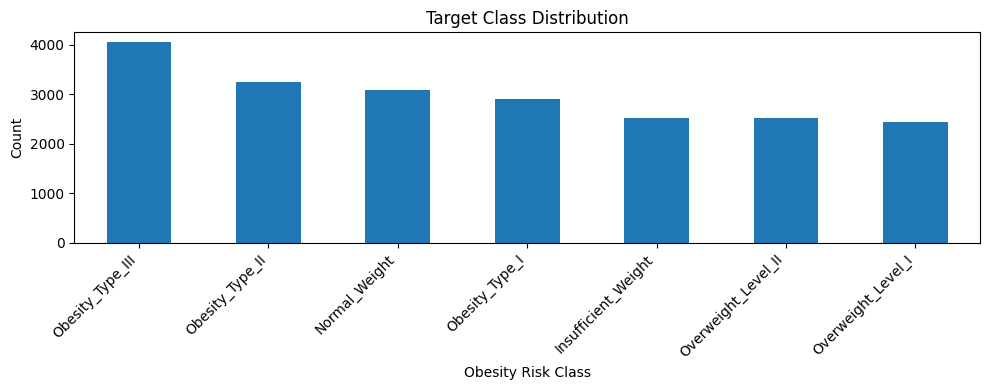

In [4]:
# ============================================================
# 3. Data audit
# ============================================================

TARGET = "NObeyesdad"
ID_COL = "id"

print("Columns:")
print(train.columns.tolist())

print("\nMissing values in train:")
display(train.isna().sum().sort_values(ascending=False).head(20))

print("\nMissing values in test:")
display(test.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

print("\nTarget distribution:")
target_counts = train[TARGET].value_counts()
target_dist = train[TARGET].value_counts(normalize=True).rename("proportion")
display(pd.concat([target_counts.rename("count"), target_dist], axis=1))

plt.figure(figsize=(10, 4))
target_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.ylabel("Count")
plt.xlabel("Obesity Risk Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [5]:
# ============================================================
# 4. Identify feature types
# ============================================================

feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]

X = train[feature_cols].copy()
y_raw = train[TARGET].copy()
X_test = test[feature_cols].copy()

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

display(X[numeric_features].describe().T)
display(X[categorical_features].describe().T)


Numeric features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


,count,mean,std,min,25%,50%,75%,max
Age,20758.0,23.841804,5.688072,14.00,20.000000,22.815416,26.000000,61.000000
Height,20758.0,1.700245,0.087312,1.45,1.631856,1.700000,1.762887,1.975663
Weight,20758.0,87.887768,26.379443,39.00,66.000000,84.064875,111.600553,165.057269
FCVC,20758.0,2.445908,0.533218,1.00,2.000000,2.393837,3.000000,3.000000
NCP,20758.0,2.761332,0.705375,1.00,3.000000,3.000000,3.000000,4.000000
CH2O,20758.0,2.029418,0.608467,1.00,1.792022,2.000000,2.549617,3.000000
FAF,20758.0,0.981747,0.838302,0.00,0.008013,1.000000,1.587406,3.000000
TUE,20758.0,0.616756,0.602113,0.00,0.000000,0.573887,1.000000,2.000000


,count,unique,top,freq
Gender,20758,2,Female,10422
family_history_with_overweight,20758,2,yes,17014
FAVC,20758,2,yes,18982
CAEC,20758,4,Sometimes,17529
SMOKE,20758,2,no,20513
SCC,20758,2,no,20071
CALC,20758,3,Sometimes,15066
MTRANS,20758,5,Public_Transportation,16687


## 4. Feature engineering

The original data already contains useful health and lifestyle predictors. The notebook adds simple, interpretable features:

- `BMI = Weight / Height^2`, because obesity risk is strongly related to body-mass index.
- `Age_BMI = Age * BMI`, to capture age-adjusted weight-risk patterns.
- `Hydration_per_weight = CH2O / Weight`, when the required columns exist.

These features are intentionally simple and explainable.


In [6]:
# ============================================================
# 5. Feature engineering
# ============================================================

def add_features(df):
    df = df.copy()
    if {"Weight", "Height"}.issubset(df.columns):
        df["BMI"] = df["Weight"] / (df["Height"] ** 2)
    if {"Age", "BMI"}.issubset(df.columns):
        df["Age_BMI"] = df["Age"] * df["BMI"]
    if {"CH2O", "Weight"}.issubset(df.columns):
        df["Hydration_per_weight"] = df["CH2O"] / df["Weight"]
    return df

X_fe = add_features(X)
X_test_fe = add_features(X_test)

categorical_features = X_fe.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_fe.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Feature-engineered train shape:", X_fe.shape)
print("Feature-engineered test shape:", X_test_fe.shape)
print("New numeric features:", [c for c in ["BMI", "Age_BMI", "Hydration_per_weight"] if c in X_fe.columns])


Feature-engineered train shape: (20758, 19)
Feature-engineered test shape: (13840, 19)
New numeric features: ['BMI', 'Age_BMI', 'Hydration_per_weight']


In [7]:
# ============================================================
# 6. Encode target and create stratified validation split
# ============================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

class_mapping = pd.DataFrame({
    "encoded_class": range(len(label_encoder.classes_)),
    "label": label_encoder.classes_
})
display(class_mapping)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_fe,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])


,encoded_class,label
0,0,Insufficient_Weight
1,1,Normal_Weight
2,2,Obesity_Type_I
3,3,Obesity_Type_II
4,4,Obesity_Type_III
5,5,Overweight_Level_I
6,6,Overweight_Level_II


Training rows: 16606
Validation rows: 4152


## 5. Preprocessing pipeline

Categorical predictors are one-hot encoded. Numeric predictors are median-imputed. Scaling is not required for tree-based models because split decisions depend on feature thresholds rather than distance or coefficient magnitude.


In [8]:
# ============================================================
# 7. Preprocessing
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

def get_feature_names(fitted_preprocessor):
    names = []
    names.extend(numeric_features)
    if len(categorical_features) > 0:
        cat_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
        names.extend(cat_encoder.get_feature_names_out(categorical_features).tolist())
    return names


## 6. Train the four required models

The four required models are:

1. **Decision Tree:** interpretable single tree, but high variance and prone to overfitting.
2. **Bagging:** many trees trained on bootstrap samples; reduces variance.
3. **Random Forest:** bagging plus random feature selection at splits; further decorrelates trees.
4. **Boosted Trees:** sequential ensemble that learns from previous errors; often strong predictive performance.


In [9]:
# ============================================================
# 8. Define models
# ============================================================

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=25,
        random_state=RANDOM_STATE
    ),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=None,
            min_samples_leaf=5,
            random_state=RANDOM_STATE
        ),
        n_estimators=300,
        max_samples=0.85,
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "Boosting": HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=350,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

pipelines


{'Decision Tree': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['Age', 'Height', 'Weight',
                                                    'FCVC', 'NCP', 'CH2O', 'FAF',
                                                    'TUE', 'BMI', 'Age_BMI',
                                                    'Hydration_per_weight']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                                                                    

In [10]:
# ============================================================
# 9. Train and validate models
# ============================================================

results = []
fitted_models = {}
valid_predictions = {}

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    acc = accuracy_score(y_valid, pred)

    fitted_models[name] = pipe
    valid_predictions[name] = pred

    results.append({
        "Model": name,
        "Validation Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Validation Accuracy", ascending=False).reset_index(drop=True)
display(results_df)


Training Decision Tree...
Training Bagging...
Training Random Forest...
Training Boosting...


,Model,Validation Accuracy
0,Boosting,0.905106
1,Random Forest,0.902457
2,Bagging,0.893304
3,Decision Tree,0.872832


In [11]:
# ============================================================
# 10. Cross-validation on the full training set
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, pipe in pipelines.items():
    print(f"Cross-validating {name}...")
    scores = cross_val_score(pipe, X_fe, y, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": scores.mean(),
        "CV Accuracy Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV Accuracy Mean", ascending=False).reset_index(drop=True)
display(cv_results_df)


Cross-validating Decision Tree...
Cross-validating Bagging...
Cross-validating Random Forest...
Cross-validating Boosting...


,Model,CV Accuracy Mean,CV Accuracy Std
0,Boosting,0.901821,0.005949
1,Random Forest,0.899123,0.006362
2,Bagging,0.891271,0.005386
3,Decision Tree,0.866750,0.004659


## 7. Model evaluation and interpretation

Accuracy is the Kaggle evaluation metric, but the confusion matrix and class-level precision/recall/F1 are also reviewed because multi-class models can perform well overall while still confusing neighboring obesity-risk categories.


Best validation model: Boosting
Validation accuracy: 0.9051059730250481

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.94      0.94       505
      Normal_Weight       0.88      0.89      0.89       617
     Obesity_Type_I       0.88      0.88      0.88       582
    Obesity_Type_II       0.96      0.98      0.97       650
   Obesity_Type_III       0.99      1.00      0.99       809
 Overweight_Level_I       0.81      0.77      0.79       485
Overweight_Level_II       0.80      0.80      0.80       504

           accuracy                           0.91      4152
          macro avg       0.89      0.89      0.89      4152
       weighted avg       0.90      0.91      0.90      4152



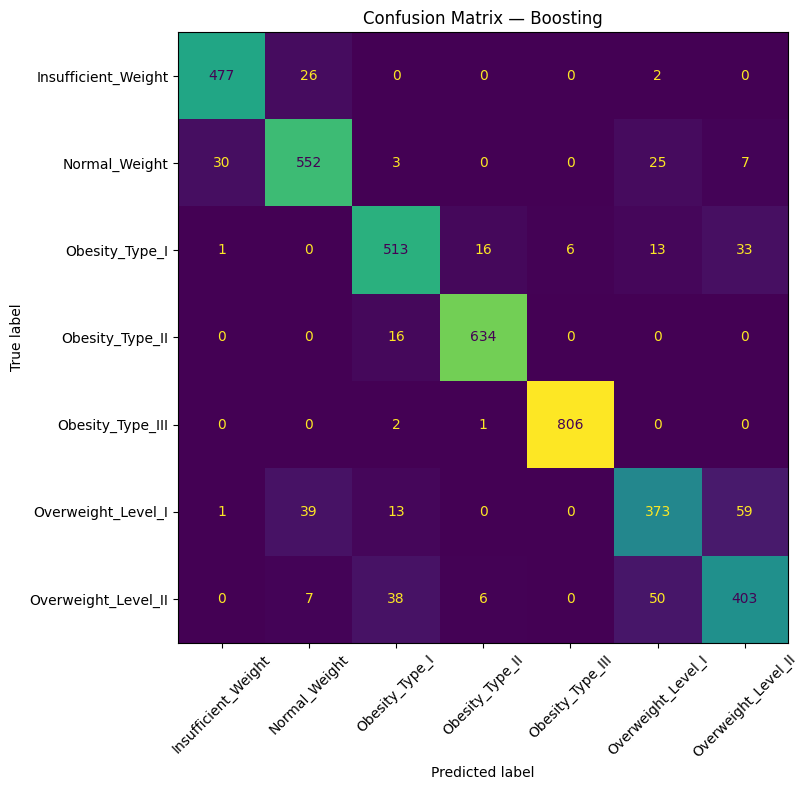

In [12]:
# ============================================================
# 11. Detailed evaluation for best validation model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_pred = valid_predictions[best_model_name]

print("Best validation model:", best_model_name)
print("Validation accuracy:", accuracy_score(y_valid, best_pred))

print("\nClassification report:")
print(classification_report(y_valid, best_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_valid, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()



Decision Tree


,feature,importance
8,BMI,0.716160
2,Weight,0.175196
12,Gender_Male,0.031032
11,Gender_Female,0.021603
10,Hydration_per_weight,0.011343
0,Age,0.008233
5,CH2O,0.006724
16,FAVC_yes,0.005702
27,CALC_no,0.005130
9,Age_BMI,0.004157


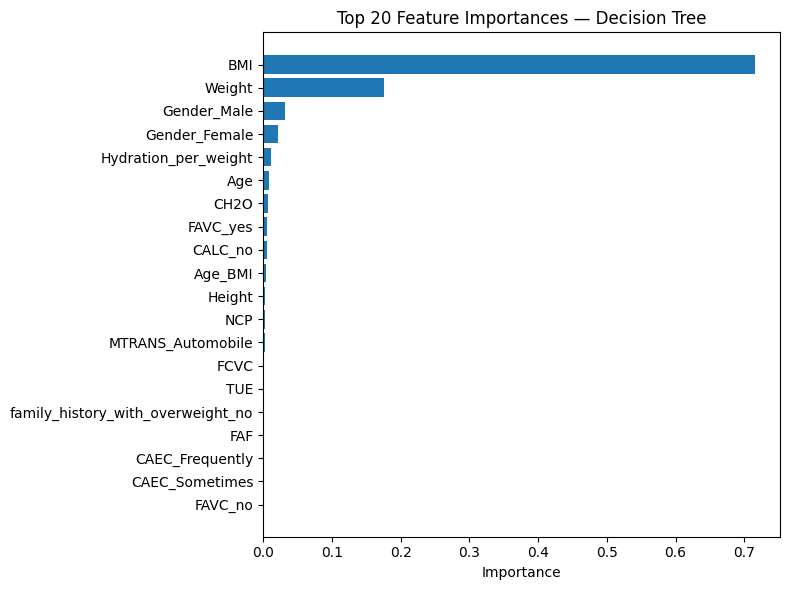


Bagging
Bagging does not expose native feature_importances_. Using permutation importance on validation data.


,feature,importance_mean,importance_std
16,BMI,0.493353,0.010325
0,Gender,0.177987,0.007307
3,Weight,0.148940,0.003861
6,FCVC,0.105829,0.005053
18,Hydration_per_weight,0.010453,0.001595
1,Age,0.008767,0.001062
17,Age_BMI,0.008622,0.000880
14,CALC,0.006696,0.001222
2,Height,0.004721,0.000994
7,NCP,0.004239,0.000447


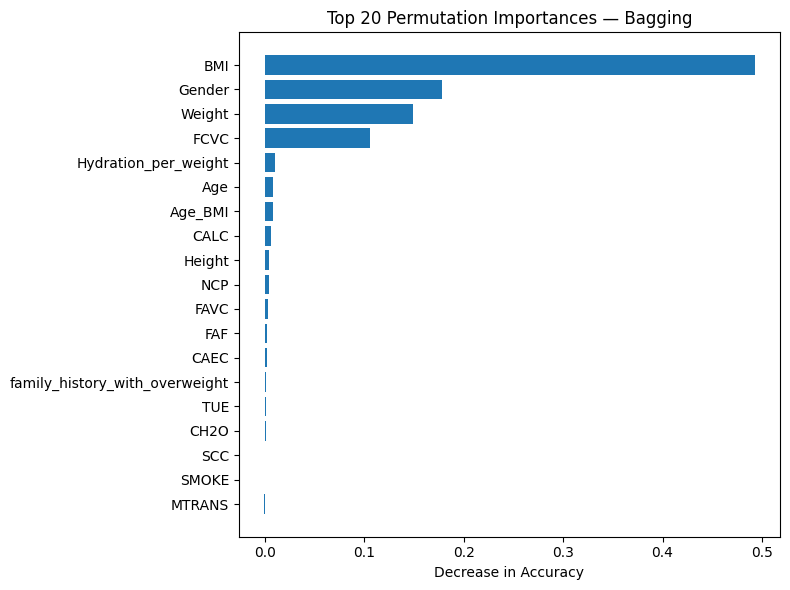


Random Forest


,feature,importance
8,BMI,0.246128
2,Weight,0.194184
9,Age_BMI,0.125848
3,FCVC,0.058382
10,Hydration_per_weight,0.054978
0,Age,0.047382
1,Height,0.045778
11,Gender_Female,0.039067
12,Gender_Male,0.037725
5,CH2O,0.025871


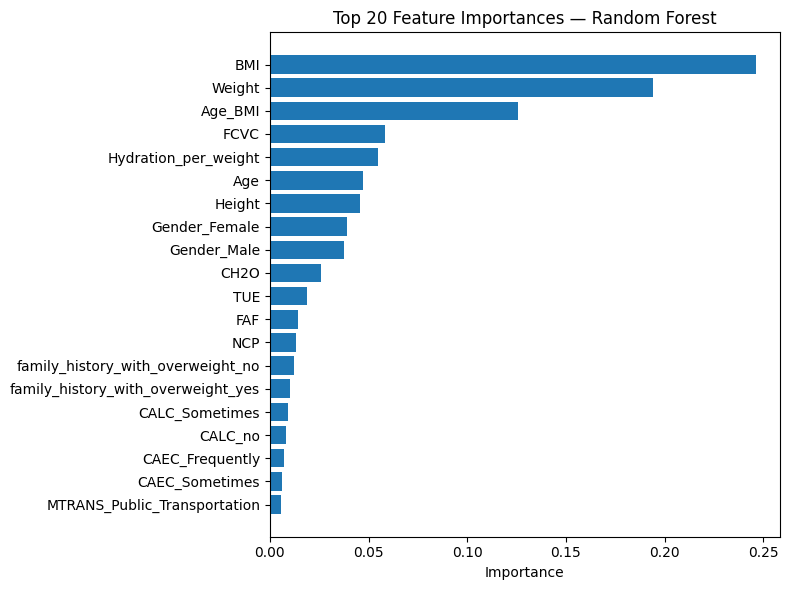


Boosting
Boosting does not expose native feature_importances_. Using permutation importance on validation data.


,feature,importance_mean,importance_std
3,Weight,0.251975,0.002666
16,BMI,0.234200,0.001912
0,Gender,0.144220,0.004946
6,FCVC,0.125482,0.005213
10,CH2O,0.013439,0.000558
1,Age,0.012139,0.001316
17,Age_BMI,0.010356,0.002089
13,TUE,0.008478,0.001678
7,NCP,0.008237,0.001971
18,Hydration_per_weight,0.007803,0.001073


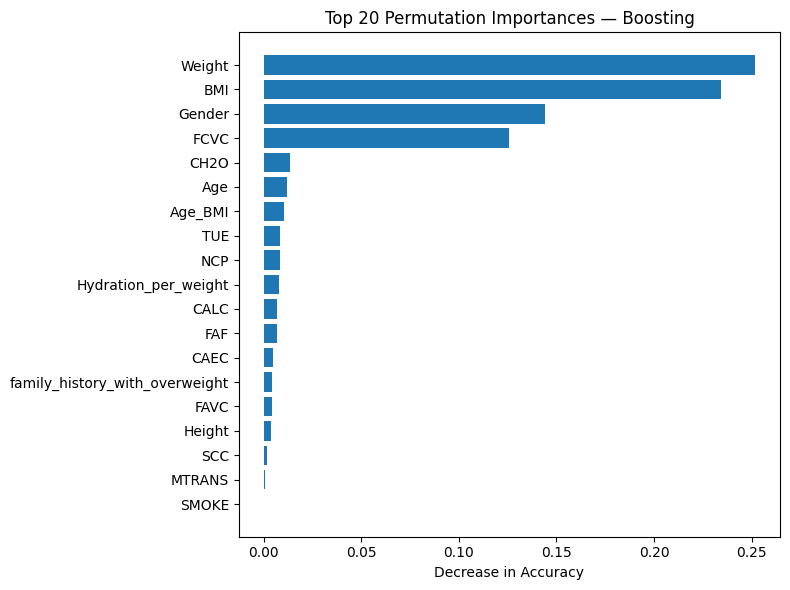

In [13]:
# ============================================================
# 12. Feature importance / model interpretation
# ============================================================

def plot_top_importances(model_name, top_n=20):
    pipe = fitted_models[model_name]
    fitted_preprocessor = pipe.named_steps["preprocess"]
    model = pipe.named_steps["model"]
    feature_names = get_feature_names(fitted_preprocessor)

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        imp_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False).head(top_n)

        display(imp_df)
        plt.figure(figsize=(8, 6))
        plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
        plt.title(f"Top {top_n} Feature Importances — {model_name}")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{model_name} does not expose native feature_importances_. Using permutation importance on validation data.")
        perm = permutation_importance(
            pipe,
            X_valid,
            y_valid,
            n_repeats=5,
            random_state=RANDOM_STATE,
            scoring="accuracy",
            n_jobs=-1
        )
        imp_df = pd.DataFrame({
            "feature": X_valid.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std
        }).sort_values("importance_mean", ascending=False).head(top_n)

        display(imp_df)
        plt.figure(figsize=(8, 6))
        plt.barh(imp_df["feature"][::-1], imp_df["importance_mean"][::-1])
        plt.title(f"Top {top_n} Permutation Importances — {model_name}")
        plt.xlabel("Decrease in Accuracy")
        plt.tight_layout()
        plt.show()

for name in ["Decision Tree", "Bagging", "Random Forest", "Boosting"]:
    print("\n" + "="*80)
    print(name)
    print("="*80)
    plot_top_importances(name, top_n=20)


## 8. Interpret the single decision tree

The single decision tree is the most transparent model. The tree diagram below shows the main split rules. In this problem, weight/BMI-related variables are expected to appear near the top of the tree because they directly separate obesity categories. Lifestyle and eating-habit variables may refine boundary cases between neighboring categories.


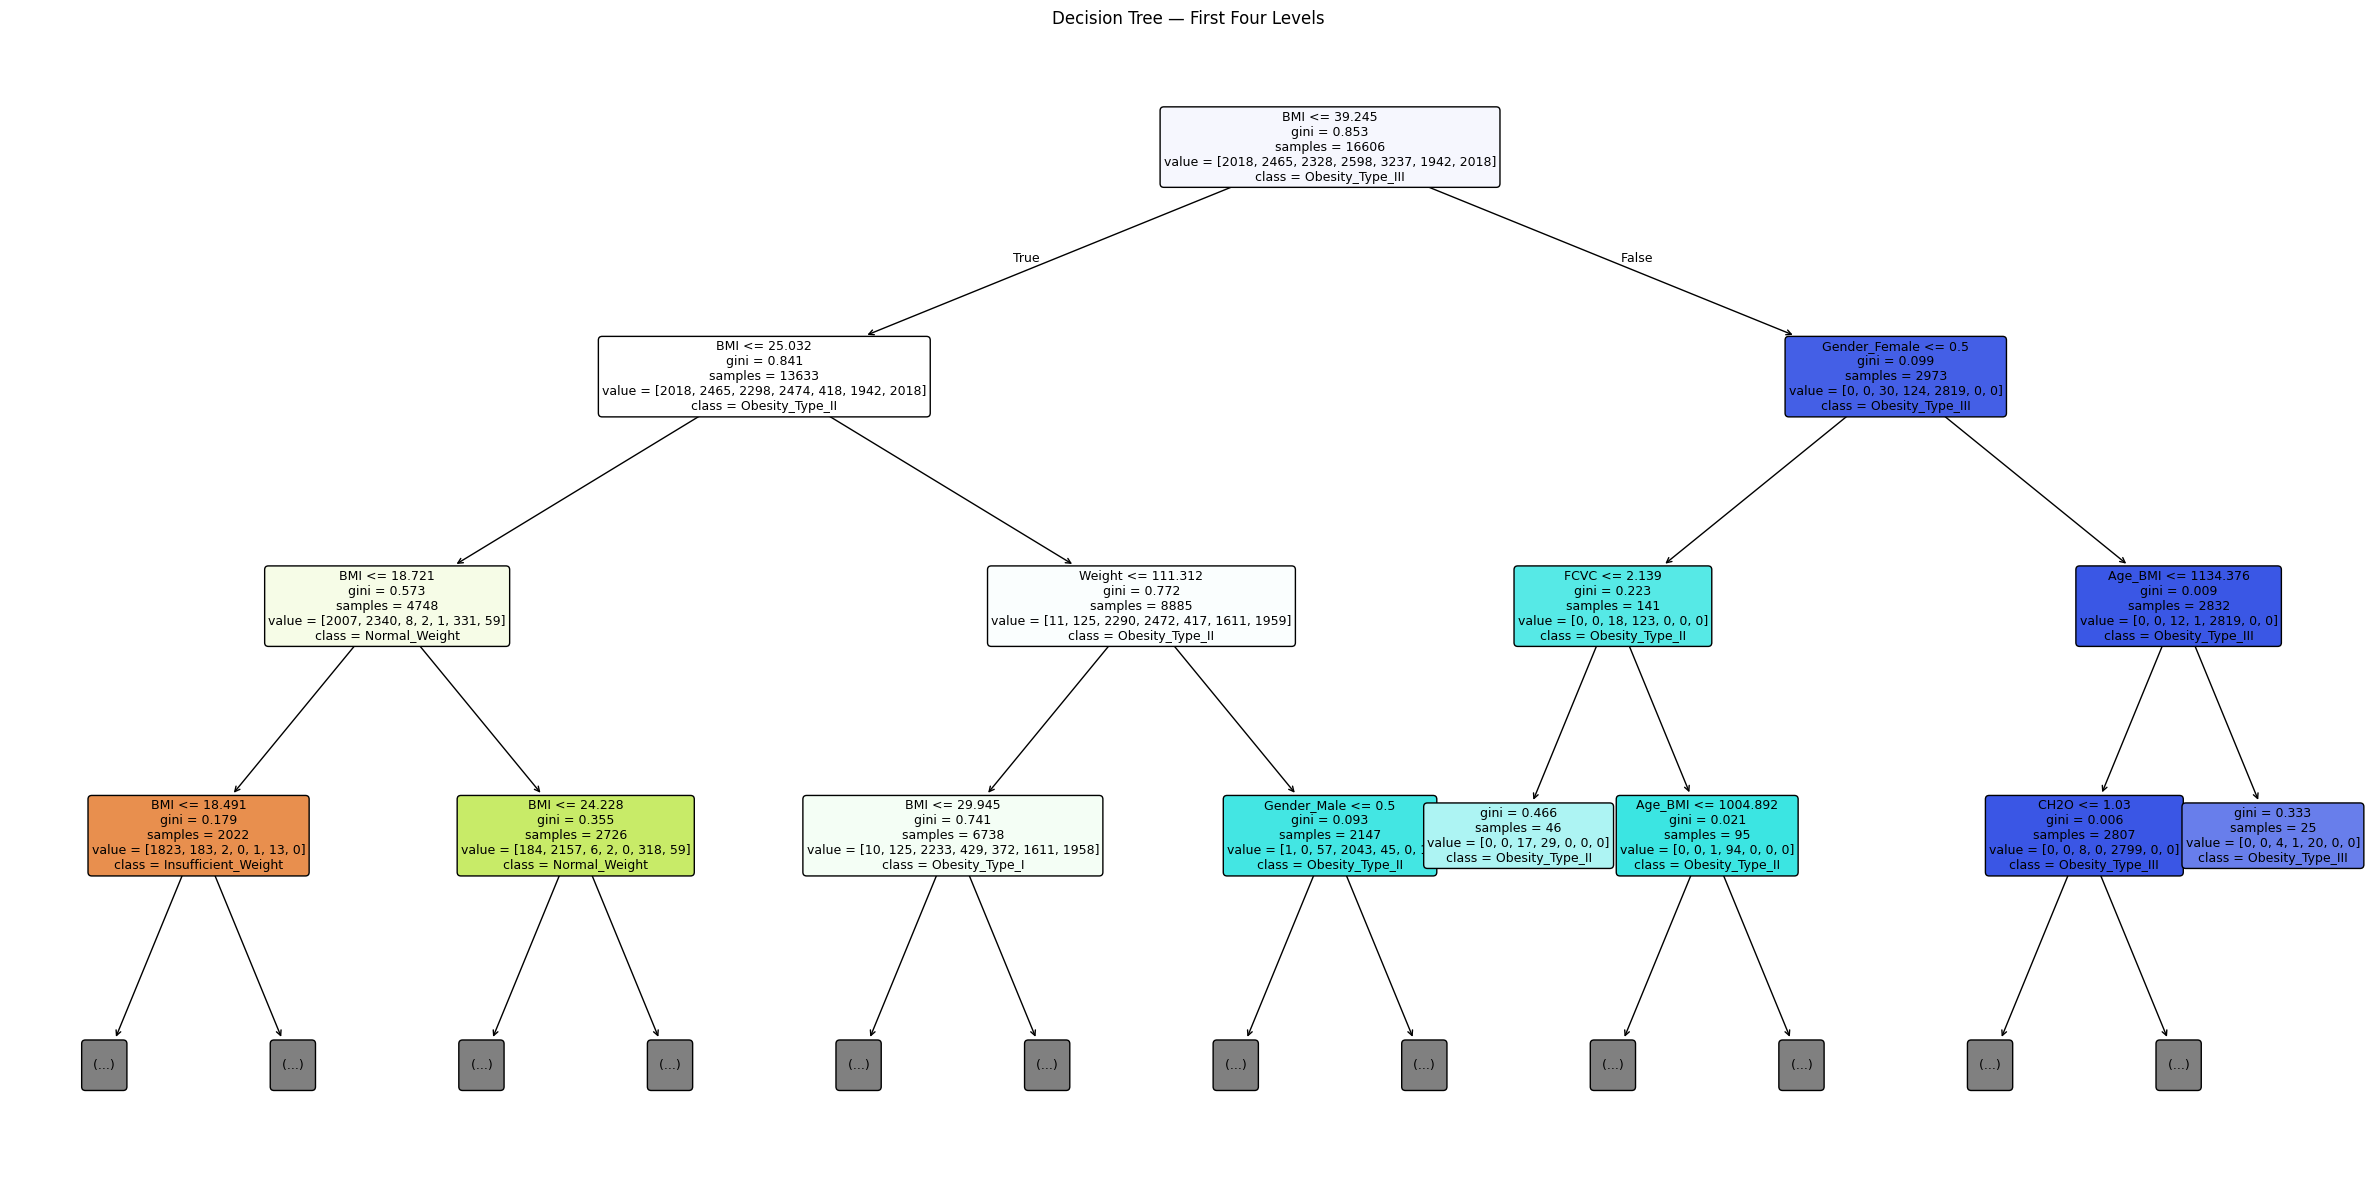

In [16]:
# ============================================================
# 13. Plot decision tree
# ============================================================

dt_pipe = fitted_models["Decision Tree"]
dt_preprocessor = dt_pipe.named_steps["preprocess"]
dt_model = dt_pipe.named_steps["model"]
dt_feature_names = get_feature_names(dt_preprocessor)

plt.figure(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=dt_feature_names,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree — First Four Levels")
plt.tight_layout()
plt.show()


## 9. Assumption investigation and findings

Use the output above to complete the written interpretation. The expected interpretation pattern is:

- **Decision Tree:** easiest to interpret, but usually less accurate because one tree has high variance.
- **Bagging:** improves stability by averaging many bootstrapped trees, but may still use very similar dominant predictors across trees.
- **Random Forest:** usually improves bagging by randomly selecting candidate predictors at each split, reducing correlation among trees.
- **Boosting:** often performs best or near-best because it builds trees sequentially and focuses on errors from earlier trees.

For this obesity-risk classification problem, the most important predictors are expected to be weight/BMI-related variables, followed by age, height, family history of overweight, and eating/lifestyle variables. Misclassifications are most likely between adjacent categories such as `Overweight_Level_I` vs. `Overweight_Level_II` or `Obesity_Type_I` vs. `Obesity_Type_II`, because these categories are naturally close on the obesity-risk scale.


In [17]:
# ============================================================
# 14. Error analysis table: most common confusion pairs
# ============================================================

error_df = pd.DataFrame({
    "actual": label_encoder.inverse_transform(y_valid),
    "predicted": label_encoder.inverse_transform(best_pred)
})

errors_only = error_df[error_df["actual"] != error_df["predicted"]]

confusion_pairs = (
    errors_only
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(confusion_pairs.head(15))


,actual,predicted,count
17,Overweight_Level_I,Overweight_Level_II,59
21,Overweight_Level_II,Overweight_Level_I,50
15,Overweight_Level_I,Normal_Weight,39
19,Overweight_Level_II,Obesity_Type_I,38
10,Obesity_Type_I,Overweight_Level_II,33
2,Normal_Weight,Insufficient_Weight,30
0,Insufficient_Weight,Normal_Weight,26
4,Normal_Weight,Overweight_Level_I,25
11,Obesity_Type_II,Obesity_Type_I,16
7,Obesity_Type_I,Obesity_Type_II,16


## 10. Fit final model and create Kaggle submission

The final submission uses the best model based on validation accuracy. For late submission, upload the generated `submission.csv` file to the Kaggle competition page.


In [22]:
# ============================================================
# 15. Fit final model on all labeled data and create submission
# ============================================================

final_model_name = results_df.iloc[0]["Model"]
final_model = pipelines[final_model_name]

print("Final model selected:", final_model_name)

final_model.fit(X_fe, y)
test_pred_encoded = final_model.predict(X_test_fe)
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)

submission = sample_submission.copy()
submission[TARGET] = test_pred_labels

submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)

print("Saved:", submission_path)
display(submission.head())
display(submission[TARGET].value_counts())


Final model selected: Boosting
Saved: submission.csv


,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


NObeyesdad
Obesity_Type_III       2622
Obesity_Type_II        2129
Normal_Weight          2118
Obesity_Type_I         2045
Overweight_Level_II    1752
Insufficient_Weight    1721
Overweight_Level_I     1453
Name: count, dtype: int64